In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_excel("EastWestAirlines.xlsx",sheet_name="data")
print(df.head())
print(df.info())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
0            1                  0                0               7000       0  
1            2                  0                0               6968       0  
2            4                  0                0               7034       0  
3            1                  0                0               6952       0  
4           26               2077                4               6935       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 en

In [3]:
df = df.dropna()

In [20]:
df_numeric = df.select_dtypes(include=[np.number])

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

df_numeric = df_numeric[~((df_numeric < (Q1 - 1.5 * IQR)) | 
                          (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]

In [27]:
df_numeric = df.select_dtypes(include=[np.number])
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

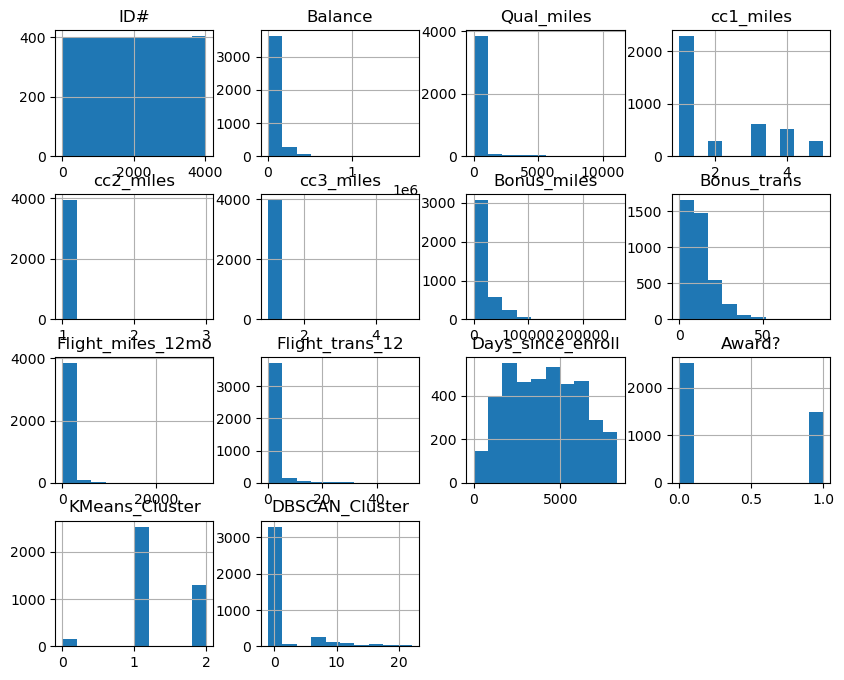

In [28]:
# Distribution
df_numeric.hist(figsize=(10,8))
plt.show()

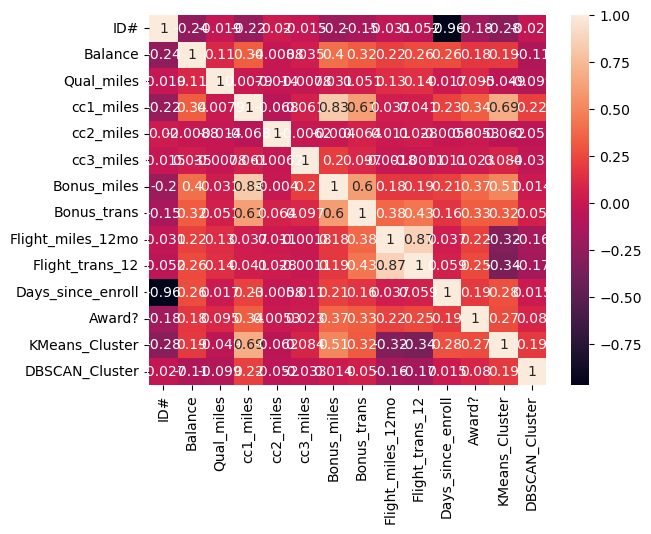

In [29]:
# Correlation heatmap
sns.heatmap(df_numeric.corr(), annot=True)
plt.show()

E:\Users\SUGANYA P\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


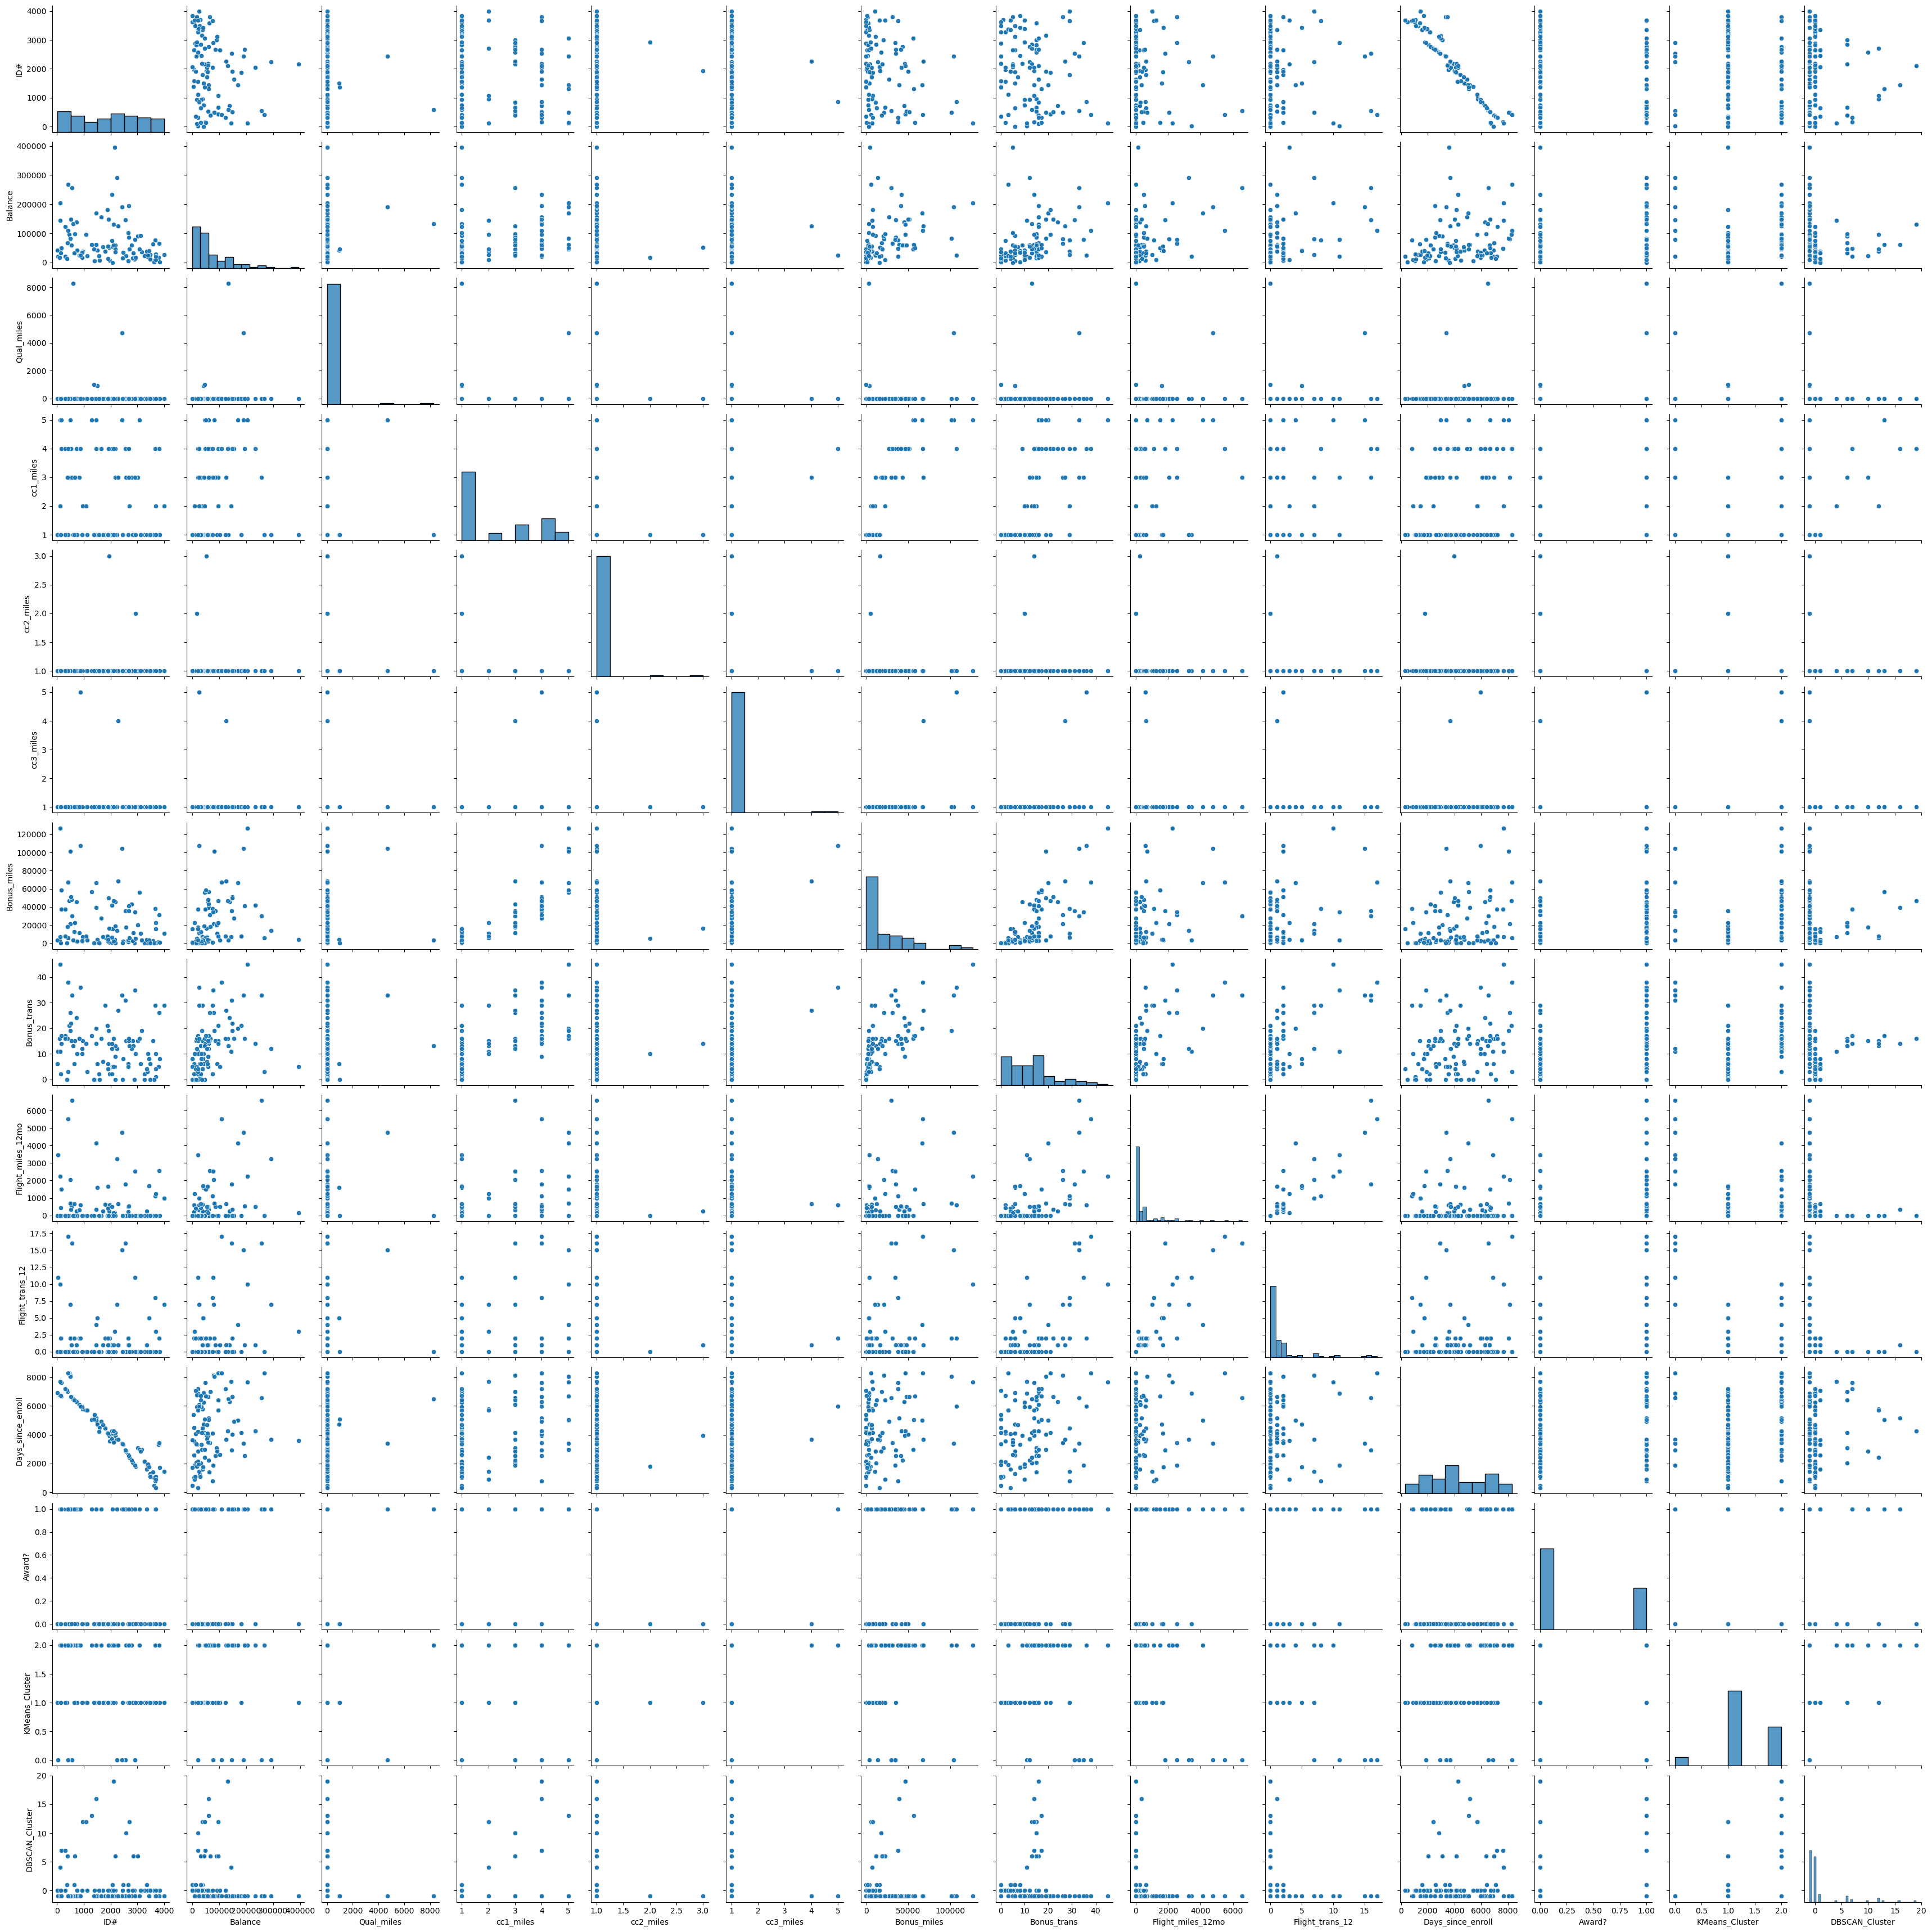

In [30]:
# Pairplot
sns.pairplot(df_numeric.sample(100))
plt.show()

E:\Users\SUGANYA P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
E:\Users\SUGANYA P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
E:\Users\SUGANYA P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
E:\Users\SUGANYA P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. 

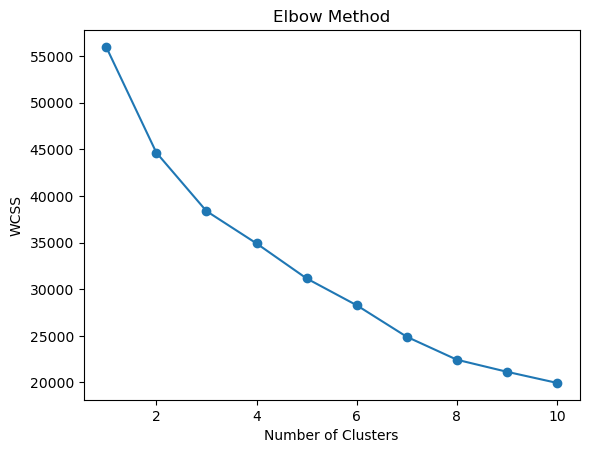

In [31]:
#KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [32]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'] = kmeans_labels

E:\Users\SUGANYA P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [33]:
kmeans_score = silhouette_score(scaled_data, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.3246462065078049


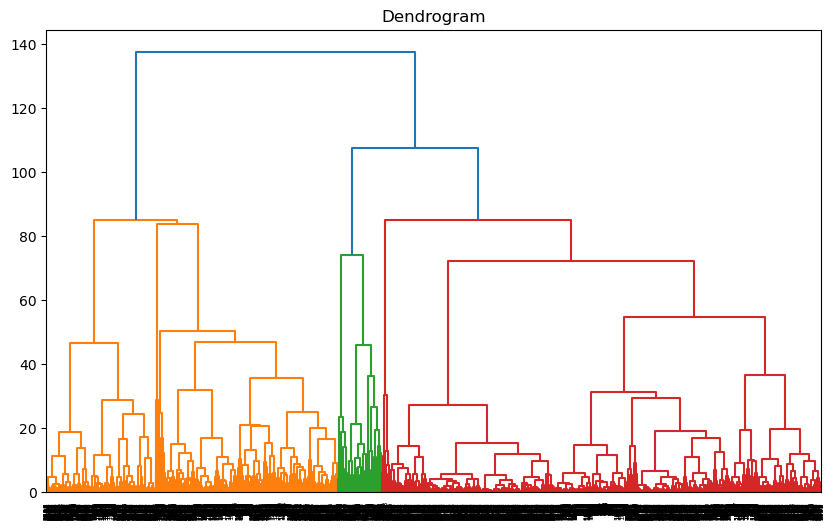

In [34]:
#hierarchical clustering
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [35]:
#dbscan clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

df['DBSCAN_Cluster'] = db_labels

In [36]:
#dbscan evaluation
if len(set(db_labels)) > 1:
    db_score = silhouette_score(scaled_data, db_labels)
    print("DBSCAN Silhouette Score:", db_score)
else:
    print("DBSCAN could not form valid clusters")

DBSCAN Silhouette Score: 0.03227902295882553


In [43]:
from sklearn.decomposition import PCA
pca_full = PCA(n_components=0.95)
pca_data = pca_full.fit_transform(scaled_data)

print("Original shape:", scaled_data.shape)
print("PCA shape:", pca_data.shape)

Original shape: (3999, 14)
PCA shape: (3999, 10)


In [44]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_labels = kmeans_pca.fit_predict(pca_data)

df['KMeans_PCA_Cluster'] = pca_labels

E:\Users\SUGANYA P\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [45]:
from sklearn.metrics import silhouette_score

score_original = silhouette_score(scaled_data, kmeans_labels)
score_pca = silhouette_score(pca_data, pca_labels)

print("KMeans Original Silhouette:", score_original)
print("KMeans PCA Silhouette:", score_pca)

KMeans Original Silhouette: 0.3246462065078049
KMeans PCA Silhouette: 0.33051876077078696


In [50]:
from sklearn.metrics import davies_bouldin_score
db_original = davies_bouldin_score(scaled_data, kmeans_labels)
db_pca = davies_bouldin_score(pca_data, pca_labels)

comparison = pd.DataFrame({
    "Model": ["KMeans Original", "KMeans PCA"],
    "Silhouette Score": [score_original, score_pca],
    "DB Index": [db_original, db_pca]
})

print(comparison)

             Model  Silhouette Score  DB Index
0  KMeans Original          0.324646  1.359128
1       KMeans PCA          0.330519  1.319565


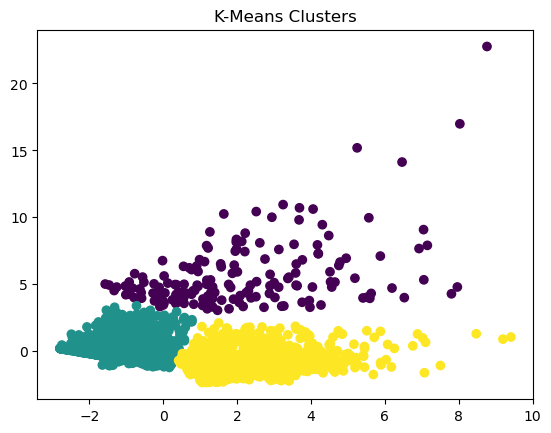

In [51]:
#KMeans plot
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=kmeans_labels)
plt.title("K-Means Clusters")
plt.show()

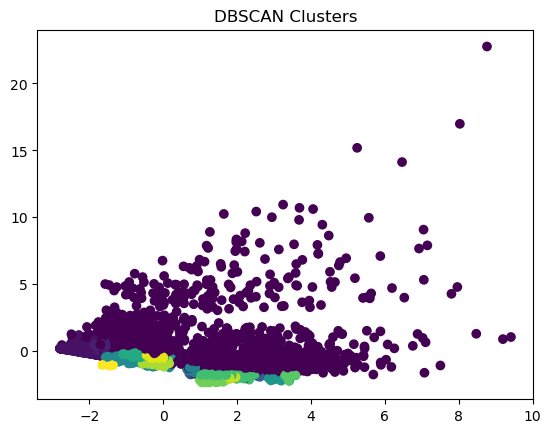

In [52]:
#dbscan plot
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=db_labels)
plt.title("DBSCAN Clusters")
plt.show()

In [53]:
print(df.head())

   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0    1    28143           0          1          1          1          174   
1    2    19244           0          1          1          1          215   
2    3    41354           0          1          1          1         4123   
3    4    14776           0          1          1          1          500   
4    5    97752           0          4          1          1        43300   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  \
0            1                  0                0               7000       0   
1            2                  0                0               6968       0   
2            4                  0                0               7034       0   
3            1                  0                0               6952       0   
4           26               2077                4               6935       1   

   KMeans_Cluster  DBSCAN_Cluster  KMeans_PCA_Clus